In [13]:
# Install a pip package in the current Jupyter kernel
#!pip install Cmake
#!pip install Cython
#!pip install setuptools wheel
#!pip install pot

In [1]:
import networkx as nx
import random
import ot
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#import seaborn as sns

In [2]:
#random.seed(30)
random.seed(42)

### GRAPH AND GRAPH MATRIX CREATION ###
# Helper function to add a random number of edges with random weights to a graph
def add_random_edges(graph, num_nodes, max_edges, max_weight=10):
  """Adds a random number of edges to a graph with random weights.
  Args:
    graph: The graph to add edges to.
    num_nodes: The number of nodes in the graph.
    max_edges: The maximum number of edges to add.
    max_weight: The maximum weight of an edge. By default set to 10.
  Returns:
    None.
    """
  for _ in range(random.randint(1, max_edges)):
    # Randomly select two different nodes and a random weight for the edge
    u, v = random.sample(range(num_nodes), 2)
    weight = random.randint(1, max_weight)
    graph.add_edge(u, v, weight=weight)


def compute_distance_matrix(graph):
  """Computes the pairwise distance matrix for a graph. Takes into account weights on edges.
  Args:
      graph: A NetworkX graph.
  Returns:
      A numpy array representing the pairwise distance matrix where the value at
      (i, j) is the shortest path length between node i and node j. If i and j are
      not connected, the distance will be set to 0 instead of inf.
  """
  # Initialize a matrix of zeros (instead of infinities)
  num_nodes = len(graph.nodes)
  distance_matrix = np.full((num_nodes, num_nodes), 10000.0)
  # distance_matrix = np.zeros((num_nodes, num_nodes))
  # Compute shortest paths and update the distance matrix
  for node in graph.nodes():
    lengths = nx.shortest_path_length(graph, source=node, weight="weight")
    for target, length in lengths.items():
      distance_matrix[node, target] = length
  return distance_matrix

In [3]:
## GENERATE GRAPHS
graph1 = nx.Graph()
graph2 = nx.Graph()
# Add vertices to each graph
nodes = range(6)
graph1.add_nodes_from(nodes)
graph2.add_nodes_from(nodes)
# Randomly add edges to the graphs
add_random_edges(graph1, 4, 6)
add_random_edges(graph2, 4, 6)

print("Graph 1 edges with weights:")
for u, v, weight in graph1.edges(data=True):
  print(f"{u} -- {v}, weight: {weight['weight']}")
print("\nGraph 2 edges with weights:")
for u, v, weight in graph2.edges(data=True):
  print(f"{u} -- {v}, weight: {weight['weight']}")

Graph 1 edges with weights:
0 -- 3, weight: 2
0 -- 1, weight: 9
0 -- 2, weight: 7

Graph 2 edges with weights:
0 -- 2, weight: 3
0 -- 3, weight: 8
0 -- 1, weight: 6
1 -- 3, weight: 5


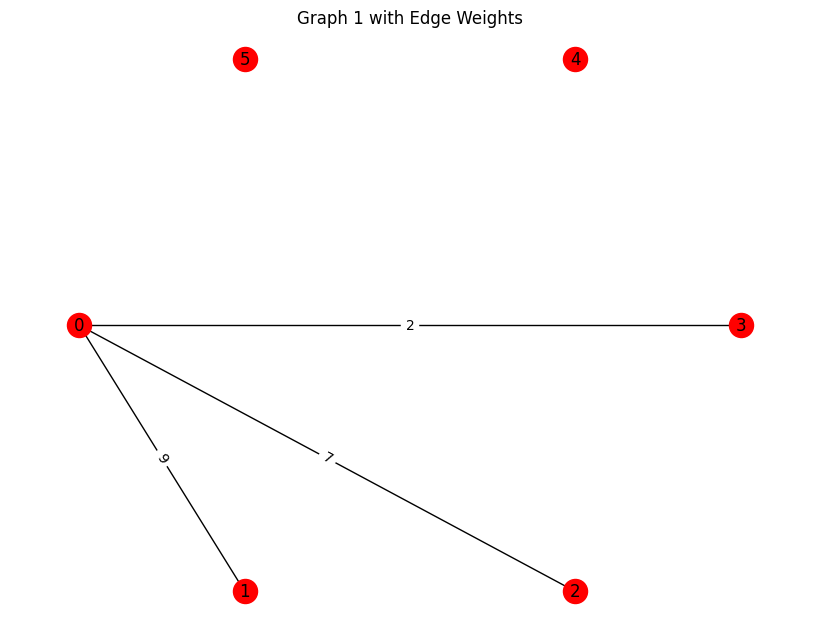

In [4]:
# Visualize graph1
plt.figure(figsize=(8, 6))
pos = nx.shell_layout(graph1)  # Generate position layout
nx.draw(graph1, pos, with_labels=True, node_color='red', edge_color='black')
edge_labels = nx.get_edge_attributes(graph1, 'weight')
nx.draw_networkx_edge_labels(graph1, pos, edge_labels=edge_labels)
plt.title("Graph 1 with Edge Weights")
plt.show()

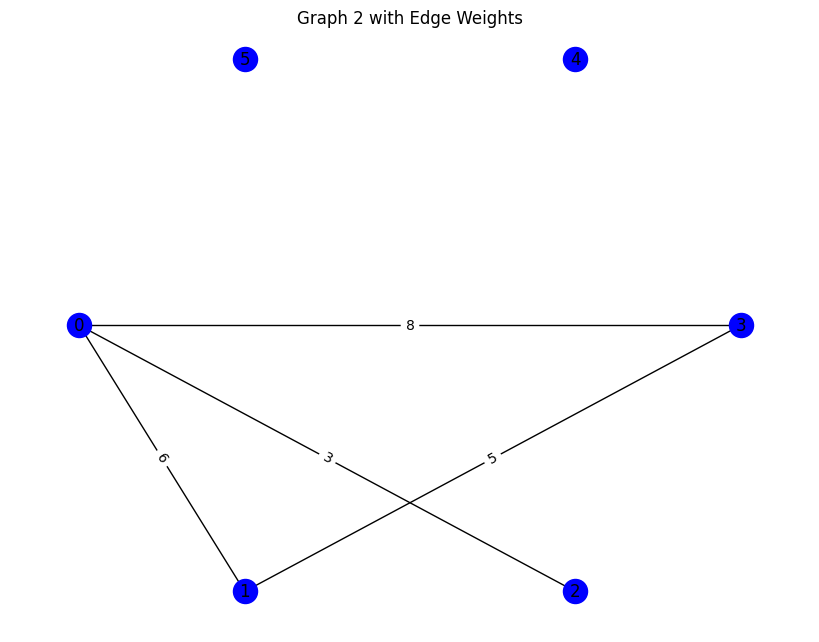

In [5]:
# Visualize graph2
plt.figure(figsize=(8, 6))
pos = nx.shell_layout(graph2)  # Generate position layout
nx.draw(graph2, pos, with_labels=True, node_color='blue', edge_color='black')
edge_labels = nx.get_edge_attributes(graph2, 'weight')
nx.draw_networkx_edge_labels(graph2, pos, edge_labels=edge_labels)
plt.title("Graph 2 with Edge Weights")
plt.show()

In [6]:
### OT VISUALIZATIONS ###
def convert_graph_to_visualizable(graph1, graph2, transport_plan):
  """Converts graphs according to the transport plan to highlight major connections and refinements.
  Args:
    graph1: First NetworkX graph.
    graph2: Second NetworkX graph.
    transport_plan: Transport plan as a numpy array.
  Returns:
    A new NetworkX graph representing transformed connections.
  """
  new_graph = nx.Graph()
  # Adding nodes
  for i, row in enumerate(transport_plan):
    max_j_index = np.argmax(row)
    new_graph.add_node((i, max_j_index), label=f"{i}->{max_j_index}")
  # Refine edge addition strategy
  for i, j in graph1.edges():
    for k, l in graph2.edges():
      i_matched = np.argmax(
          transport_plan[i])  # Match for i in graph1 to graph2
      j_matched = np.argmax(
          transport_plan[j])  # Match for j in graph1 to graph2
      if (i_matched == k and j_matched == l) or (i_matched == l
                                                 and j_matched == k):
        new_graph.add_edge((i, i_matched), (j, j_matched))
  return new_graph


def convert_graph(graph1, graph2):
  """Returns the Gromov-Wasserstein transport map between two graphs.
  Args:
    graph1: A NetworkX graph.
    graph2: A NetworkX graph.
  Returns:
    The transport map between the two graphs visualized as a graph."""
  order_matrix1 = compute_distance_matrix(graph1)
  order_matrix2 = compute_distance_matrix(graph2)
  print("Pairwise distance matrix for graph1:")
  print(order_matrix1)
  print("Pairwise distance matrix for graph2:")
  print(order_matrix2)
  # Determine transport plan using Gromov-Wasserstein transport
  transport_plan = ot.gromov.gromov_wasserstein(order_matrix1,
                                                order_matrix2,
                                                loss_fun='square_loss')
  # Convert transport_plan matrix back to a graph for visualization
  visualizable_graph = convert_graph_to_visualizable(graph1, graph2,
                                                     transport_plan)
  return visualizable_graph, transport_plan


Pairwise distance matrix for graph1:
[[0.0e+00 9.0e+00 7.0e+00 2.0e+00 1.0e+04 1.0e+04]
 [9.0e+00 0.0e+00 1.6e+01 1.1e+01 1.0e+04 1.0e+04]
 [7.0e+00 1.6e+01 0.0e+00 9.0e+00 1.0e+04 1.0e+04]
 [2.0e+00 1.1e+01 9.0e+00 0.0e+00 1.0e+04 1.0e+04]
 [1.0e+04 1.0e+04 1.0e+04 1.0e+04 0.0e+00 1.0e+04]
 [1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 0.0e+00]]
Pairwise distance matrix for graph2:
[[0.0e+00 6.0e+00 3.0e+00 8.0e+00 1.0e+04 1.0e+04]
 [6.0e+00 0.0e+00 9.0e+00 5.0e+00 1.0e+04 1.0e+04]
 [3.0e+00 9.0e+00 0.0e+00 1.1e+01 1.0e+04 1.0e+04]
 [8.0e+00 5.0e+00 1.1e+01 0.0e+00 1.0e+04 1.0e+04]
 [1.0e+04 1.0e+04 1.0e+04 1.0e+04 0.0e+00 1.0e+04]
 [1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 0.0e+00]]
Optimal transport plan:
[[0.16666667 0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.16666667 0.         0.        ]
 [0.         0.         0.16666667 0.         0.         0.        ]
 [0.         0.16666667 0.         0.         0.         0.        ]
 [0.        

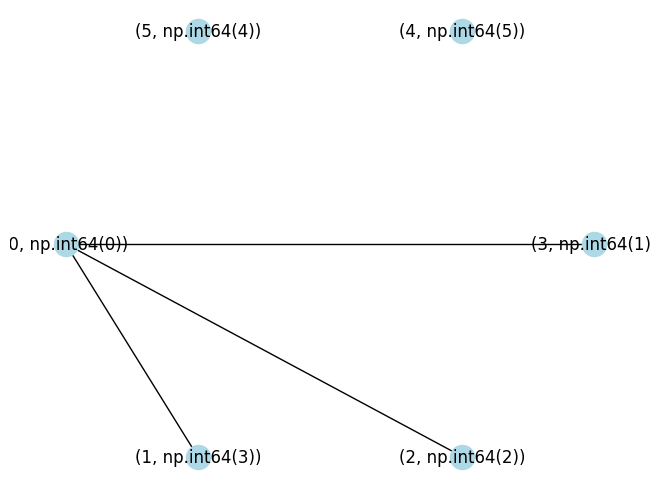

In [7]:
## Perform optimal transport and visualize the output as a graph
visualizable_graph, transport_plan = convert_graph(graph1, graph2)
print("Optimal transport plan:")
print(transport_plan)
# Visualizing and saving the resulting graph
plt.figure()
pos = nx.shell_layout(visualizable_graph)
nx.draw(visualizable_graph, pos, with_labels=True, node_color='lightblue')
plt.show()

In [8]:
### COMPUTATION OF BARYCENTERS AND VISUALIZATIONS ###
def compute_gromov_wasserstein_barycenter(graph1, graph2, weights,
                                          num_nodes_barycenter):
  # Compute distance matrices for both graphs
  distance_matrix1 = compute_distance_matrix(graph1)
  distance_matrix2 = compute_distance_matrix(graph2)

  # Prepare the list of distance matrices and weights
  distance_matrices = [distance_matrix1, distance_matrix2]

  # Compute the barycenter's distance matrix
  barycenter_matrix = ot.gromov.gromov_barycenters(N=num_nodes_barycenter,
                                                   Cs=distance_matrices,
                                                   lambdas=weights,
                                                   loss_fun='square_loss',
                                                   random_state=30)

  return barycenter_matrix


def threshold_distance_matrix(distance_matrix, upper_threshold):
  adjacency_matrix = np.copy(distance_matrix)
  # Set distances greater than or equal to the threshold and initially set distances (indicating no connection) to 0
  adjacency_matrix[(adjacency_matrix >= upper_threshold) |
                   (adjacency_matrix == 10000.0) | (adjacency_matrix > 20)] = 0
  # Set all other positive distances to 1, indicating an edge exists
  adjacency_matrix[(adjacency_matrix < upper_threshold)
                   & (adjacency_matrix > 0)] = 1
  return adjacency_matrix


def visualize_barycenter_graph(barycenter_adjacency):
  """Visualizes the barycenter graph given the adjacency matrix.
  Args:
    barycenter_adjacency: A numpy array representing the adjacency matrix of the barycenter graph.
  """
  barycenter_graph = nx.from_numpy_array(barycenter_adjacency)
  pos = nx.kamada_kawai_layout(barycenter_graph)
  nx.draw(barycenter_graph,
          pos,
          with_labels=True,
          node_color='lightblue',
          edge_color='grey')
  plt.title("Gromov-Wasserstein Barycenter Graph Visualization")
  plt.show()

In [9]:
## REFORMULATE GRAPHS WITH UNIFORM WEIGHTS ON EDGES AND MAKE THEM CONNECTED
for (u, v, w) in graph1.edges(data=True):
    graph1[u][v]['weight'] = 10
for (u, v, w) in graph2.edges(data=True):
    graph2[u][v]['weight'] = 10
# Add edge connecting node 0 and 5 with a weight of 10 in graph1
graph1.add_edge(0, 5, weight=10)
# Add edge connecting node 5 and 4 with a weight of 10 in graph1
graph1.add_edge(5, 4, weight=10)
# Add edge connecting node 0 and 5 with a weight of 10 in graph2
graph2.add_edge(0, 5, weight=10)
# Add edge connecting node 5 and 4 with a weight of 10 in graph2
graph2.add_edge(5, 4, weight=10)
# To visualize the result, let's print out the edges of each graph

## FIND GROMOV-WASSERSTEIN BARYCENTERS AND VISUALIZE THE RESULTS
# Initialize inputs
num_nodes_barycenter = (len(graph1.nodes) + len(graph2.nodes)) // 2
# Use different sets of weights for each graph
weights_list = [[2 / 3, 1 / 3], [0.5, 0.5], [1 / 3, 2 / 3]]
# Specify an upper threshold for considering distances as edges.
# Consider distances above upper_threshold as no edges (for simplicity in visualization)
upper_threshold = (max(len(graph1.nodes),len(graph2.nodes))-1) * 10
print(upper_threshold)

50


Gromov-Wasserstein Barycenter's distance matrix: [0.6666666666666666, 0.3333333333333333]
[[ 0.         10.         20.         20.         16.66666667 30.        ]
 [10.          0.         10.         10.         10.         20.        ]
 [20.         10.          0.         20.         20.         10.        ]
 [20.         10.         20.          0.         20.         30.        ]
 [16.66666667 10.         20.         20.          0.         30.        ]
 [30.         20.         10.         30.         30.          0.        ]]
GW Barycenter adjacency matrix: [0.6666666666666666, 0.3333333333333333]
[[0. 1. 0. 0. 1. 0.]
 [1. 0. 1. 1. 1. 0.]
 [0. 1. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
Gromov-Wasserstein Barycenter's distance matrix: [0.5, 0.5]
[[ 0. 10. 20. 20. 15. 30.]
 [10.  0. 10. 10. 10. 20.]
 [20. 10.  0. 20. 20. 10.]
 [20. 10. 20.  0. 20. 30.]
 [15. 10. 20. 20.  0. 30.]
 [30. 20. 10. 30. 30.  0.]]
GW Barycenter adjacency matrix: [0.5

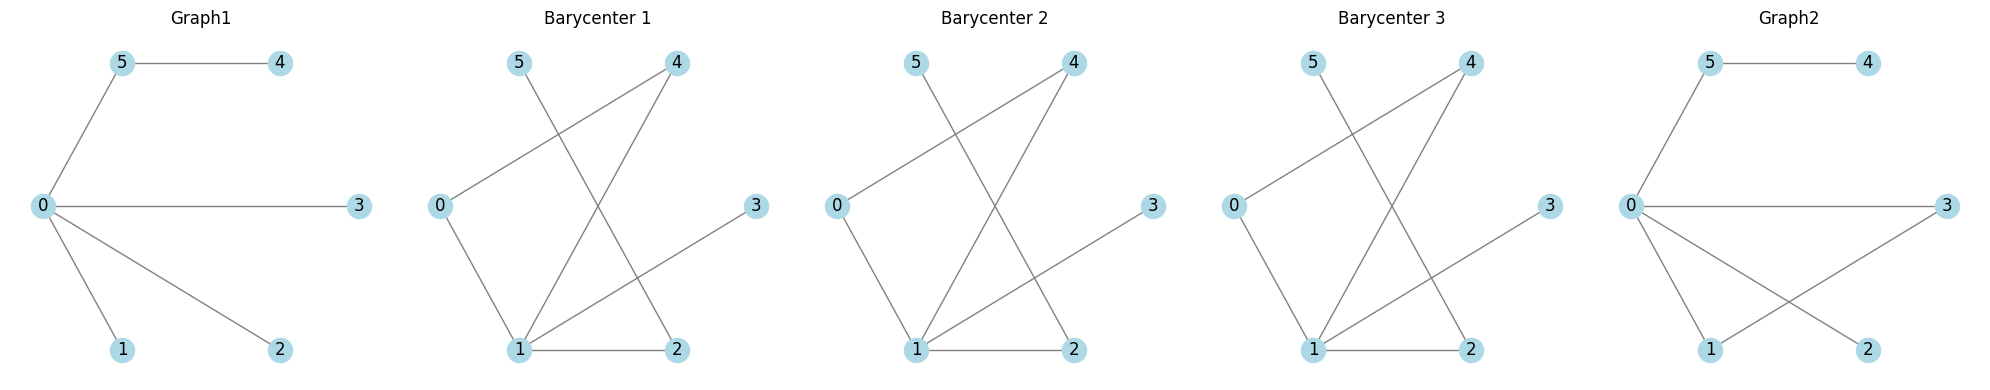

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# Visualize graph1
axes[0].set_title('Graph1')
pos = nx.shell_layout(graph1)
nx.draw(graph1,
        pos,
        ax=axes[0],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')

# Iterate over weights_list to compute and visualize barycenters
for index, weights in enumerate(weights_list):
  barycenter_matrix = compute_gromov_wasserstein_barycenter(
      graph1, graph2, weights, num_nodes_barycenter)
  print("Gromov-Wasserstein Barycenter's distance matrix:", weights)
  print(barycenter_matrix)
  # Convert the barycenter's distance matrix to an adjacency matrix using the threshold
  barycenter_adjacency = threshold_distance_matrix(barycenter_matrix,
                                                   upper_threshold)
  print("GW Barycenter adjacency matrix:", weights)
  print(barycenter_adjacency)
  # Convert adjacency matrix to graph
  barycenter_graph = nx.from_numpy_array(barycenter_adjacency)
  bary_pos = nx.shell_layout(barycenter_graph)
  axes[index + 1].set_title(f'Barycenter {index + 1}')
  nx.draw(barycenter_graph,
          bary_pos,
          ax=axes[index + 1],
          with_labels=True,
          node_color='lightblue',
          edge_color='grey')

# Visualize graph2
axes[4].set_title('Graph2')
#pos = nx.spring_layout(graph2, seed=42)
pos = nx.shell_layout(graph2)
nx.draw(graph2,
        pos,
        ax=axes[4],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
plt.tight_layout()
#plt.savefig('barycenter_graphs.png')
plt.show()

15
Gromov-Wasserstein Barycenter's distance matrix: [0.6666666666666666, 0.3333333333333333]
[[0. 3. 6. 6. 5. 9.]
 [3. 0. 3. 3. 3. 6.]
 [6. 3. 0. 6. 6. 3.]
 [6. 3. 6. 0. 6. 9.]
 [5. 3. 6. 6. 0. 9.]
 [9. 6. 3. 9. 9. 0.]]
GW Barycenter adjacency matrix: [0.6666666666666666, 0.3333333333333333]
[[0. 1. 1. 1. 1. 0.]
 [1. 0. 1. 1. 1. 1.]
 [1. 1. 0. 1. 1. 1.]
 [1. 1. 1. 0. 1. 0.]
 [1. 1. 1. 1. 0. 0.]
 [0. 1. 1. 0. 0. 0.]]
[0.3 0.6 0.6 0.5 0.3 0.3 0.3 0.6 0.6 0.6 0.3 0.6]
Gromov-Wasserstein Barycenter's distance matrix: [0.5, 0.5]
[[0.  3.  6.  6.  4.5 9. ]
 [3.  0.  3.  3.  3.  6. ]
 [6.  3.  0.  6.  6.  3. ]
 [6.  3.  6.  0.  6.  9. ]
 [4.5 3.  6.  6.  0.  9. ]
 [9.  6.  3.  9.  9.  0. ]]
GW Barycenter adjacency matrix: [0.5, 0.5]
[[0. 1. 1. 1. 1. 0.]
 [1. 0. 1. 1. 1. 1.]
 [1. 1. 0. 1. 1. 1.]
 [1. 1. 1. 0. 1. 0.]
 [1. 1. 1. 1. 0. 0.]
 [0. 1. 1. 0. 0. 0.]]
[0.3  0.6  0.6  0.45 0.3  0.3  0.3  0.6  0.6  0.6  0.3  0.6 ]
Gromov-Wasserstein Barycenter's distance matrix: [0.3333333333333333, 0.666

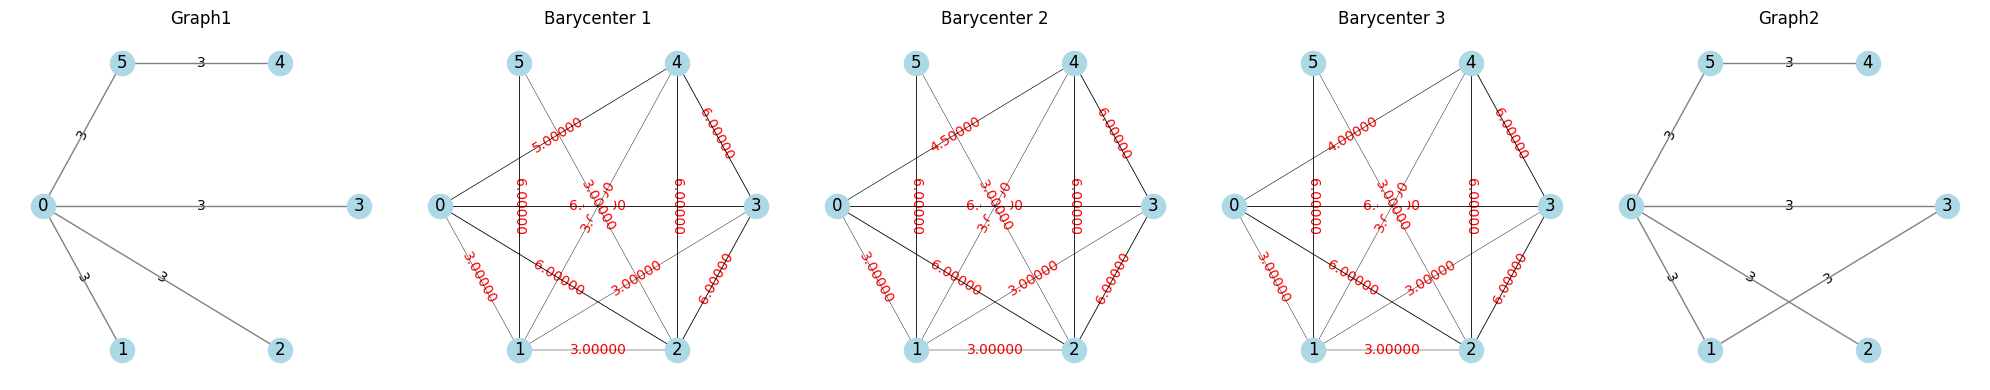

In [31]:
### ADJUST VISUALIZATION ###
def compute_gromov_wasserstein_barycenter(graph1, graph2, weights,
                                          num_nodes_barycenter):
  # Compute distance matrices for both graphs
  distance_matrix1 = compute_distance_matrix(graph1)
  distance_matrix2 = compute_distance_matrix(graph2)
  # Prepare the list of distance matrices and weights
  distance_matrices = [distance_matrix1, distance_matrix2]
  # Compute the barycenter's distance matrix
  barycenter_matrix = ot.gromov.gromov_barycenters(N=num_nodes_barycenter,
                                                   Cs=distance_matrices,
                                                   lambdas=weights,
                                                   loss_fun='square_loss',
                                                   random_state=30)
  return barycenter_matrix


def threshold_distance_matrix(distance_matrix, upper_threshold):
  adjacency_matrix = np.copy(distance_matrix)
  # Set distances greater than or equal to the threshold and initially set distances (indicating no connection) to 0
  adjacency_matrix[(adjacency_matrix >= upper_threshold) |
                   (adjacency_matrix == 10000.0) | (adjacency_matrix >= 9.0)] = 0
  # Set all other positive distances to 1, indicating an edge exists
  adjacency_matrix[(adjacency_matrix < upper_threshold)
                   & (adjacency_matrix > 0)] = 1
  return adjacency_matrix


## REFORMULATE GRAPHS WITH UNIFORM WEIGHTS ON EDGES AND MAKE THEM CONNECTED
for (u, v, w) in graph1.edges(data=True):
  graph1[u][v]['weight'] = 3
for (u, v, w) in graph2.edges(data=True):
  graph2[u][v]['weight'] = 3
# Add edge connecting node 0 and 5 with a weight of 10 in graph1
graph1.add_edge(0, 5, weight=3)
# Add edge connecting node 5 and 4 with a weight of 10 in graph1
graph1.add_edge(5, 4, weight=3)
# Add edge connecting node 0 and 5 with a weight of 10 in graph2
graph2.add_edge(0, 5, weight=3)
# Add edge connecting node 5 and 4 with a weight of 10 in graph2
graph2.add_edge(5, 4, weight=3)

## FIND GROMOV-WASSERSTEIN BARYCENTERS AND VISUALIZE THE RESULTS
# Initialize inputs
num_nodes_barycenter = (len(graph1.nodes) + len(graph2.nodes)) // 2
# Use different sets of weights for each graph
weights_list = [[2 / 3, 1 / 3], [0.5, 0.5], [1 / 3, 2 / 3]]
# Specify an upper threshold for considering distances as edges
# Consider distances above upper_threshold as no edges (for simplicity in visualization)
upper_threshold = (max(len(graph1.nodes), len(graph2.nodes)) - 1) * 3
print(upper_threshold)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax in axes:
  ax.set_facecolor('white')
# Visualize graph1
axes[0].set_title('Graph1')
pos = nx.shell_layout(graph1)
nx.draw_networkx_edge_labels(graph1,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph1.edges(data=True)
                             },
                             ax=axes[0])
nx.draw(graph1,
        pos,
        ax=axes[0],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
# Iterate over weights_list to compute and visualize barycenters
for index, weights in enumerate(weights_list):
  barycenter_matrix = compute_gromov_wasserstein_barycenter(
      graph1, graph2, weights, num_nodes_barycenter)
  print("Gromov-Wasserstein Barycenter's distance matrix:", weights)
  print(barycenter_matrix)
  # Convert the barycenter's distance matrix to an adjacency matrix using the threshold
  barycenter_adjacency = threshold_distance_matrix(barycenter_matrix,
                                                   upper_threshold)
  print("GW Barycenter adjacency matrix:", weights)
  print(barycenter_adjacency)
  # Compute edge weights for visualization
  # barycenter_edges_weight = np.exp(-barycenter_matrix) * barycenter_adjacency
  barycenter_edges_weight = barycenter_matrix * barycenter_adjacency
  # barycenter_edges_weight = barycenter_matrix * barycenter_adjacency
  # Convert adjacency matrix to graph
  barycenter_graph = nx.from_numpy_array(barycenter_adjacency,
                                         create_using=nx.Graph)
  nx.set_edge_attributes(barycenter_graph, {
      (i, j): barycenter_edges_weight[i, j]
      for i, j in barycenter_graph.edges()
  }, 'weight')
  # Scale edges based on weights
  edges, weights = zip(
      *nx.get_edge_attributes(barycenter_graph, 'weight').items())
  # Visualize with edge thickness corresponding to weight
  bary_pos = nx.shell_layout(barycenter_graph)
  axes[index + 1].set_title(f'Barycenter {index + 1}')
  widths = np.array([(w *.1) for w in weights], dtype=float)
  print(widths)
  # Ensure minimum visibility threshold
  widths[widths < 0.1] = 0.1
  nx.draw_networkx_edge_labels(
      barycenter_graph,
      bary_pos,
      edge_labels={
          (u, v): f"{d['weight']:.5f}"
          for u, v, d in barycenter_graph.edges(data=True)
      },
      font_color='red',
      ax=axes[index + 1])
  nx.draw(barycenter_graph,
          bary_pos,
          ax=axes[index + 1],
          with_labels=True,
          node_color='lightblue',
          edge_color='black',
          width=widths)
# Visualize graph2
axes[4].set_title('Graph2')
pos = nx.shell_layout(graph2)
nx.draw_networkx_edge_labels(graph2,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph2.edges(data=True)
                             },
                             ax=axes[4])
nx.draw(graph2,
        pos,
        ax=axes[4],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
plt.tight_layout()
plt.savefig('barycenter_graphs.png')
plt.show()


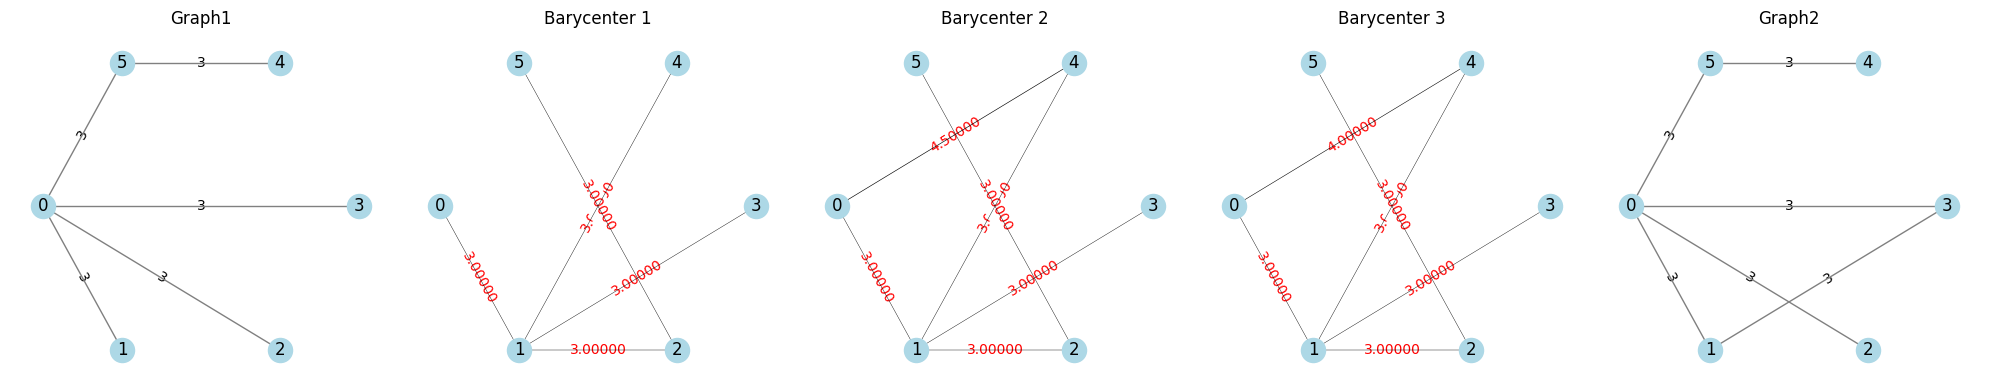

In [32]:
## DELETE UNNECESSARY EDGES
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax in axes:
  ax.set_facecolor('white')
# Visualize graph1
axes[0].set_title('Graph1')
pos = nx.shell_layout(graph1)
nx.draw_networkx_edge_labels(graph1,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph1.edges(data=True)
                             },
                             ax=axes[0])
nx.draw(graph1,
        pos,
        ax=axes[0],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
# Iterate over weights_list to compute and visualize barycenters
for index, weights in enumerate(weights_list):
  barycenter_matrix = compute_gromov_wasserstein_barycenter(
      graph1, graph2, weights, num_nodes_barycenter)
  # Convert the barycenter's distance matrix to an adjacency matrix using the threshold
  barycenter_adjacency = threshold_distance_matrix(barycenter_matrix,
                                                   upper_threshold)
  # Compute edge weights/exp for visualization
  # barycenter_edges_weight = np.exp(-barycenter_matrix) * barycenter_adjacency
  barycenter_edges_weight = barycenter_matrix * barycenter_adjacency
  # Convert adjacency matrix to graph
  barycenter_graph = nx.from_numpy_array(barycenter_adjacency,
                                         create_using=nx.Graph)
  nx.set_edge_attributes(barycenter_graph, {
      (i, j): barycenter_edges_weight[i, j]
      for i, j in barycenter_graph.edges()
  }, 'weight')
  # Filter and remove edges
  edges_to_remove = [(u, v) for u, v, d in barycenter_graph.edges(data=True)
                     if d['weight'] > 4.5]
  barycenter_graph.remove_edges_from(edges_to_remove)
  # Scale edges based on weights
  edges, weights = zip(
      *nx.get_edge_attributes(barycenter_graph, 'weight').items())
  # Visualize with edge thickness corresponding to weight
  bary_pos = nx.shell_layout(barycenter_graph)
  axes[index + 1].set_title(f'Barycenter {index + 1}')
  widths = np.array([(w *.1) for w in weights], dtype=float)
  nx.draw_networkx_edge_labels(
      barycenter_graph,
      bary_pos,
      edge_labels={
          (u, v): f"{d['weight']:.5f}"
          for u, v, d in barycenter_graph.edges(data=True)
          if (u, v) not in edges_to_remove
      },
      font_color='red',
      ax=axes[index + 1])
  nx.draw(barycenter_graph,
          bary_pos,
          ax=axes[index + 1],
          with_labels=True,
          node_color='lightblue',
          edge_color='black',
          width=widths)
# Visualize graph2
axes[4].set_title('Graph2')
pos = nx.shell_layout(graph2)
nx.draw_networkx_edge_labels(graph2,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph2.edges(data=True)
                             },
                             ax=axes[4])
nx.draw(graph2,
        pos,
        ax=axes[4],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
plt.tight_layout()
plt.savefig('barycenter_graphs_trimmed.png')
plt.show()

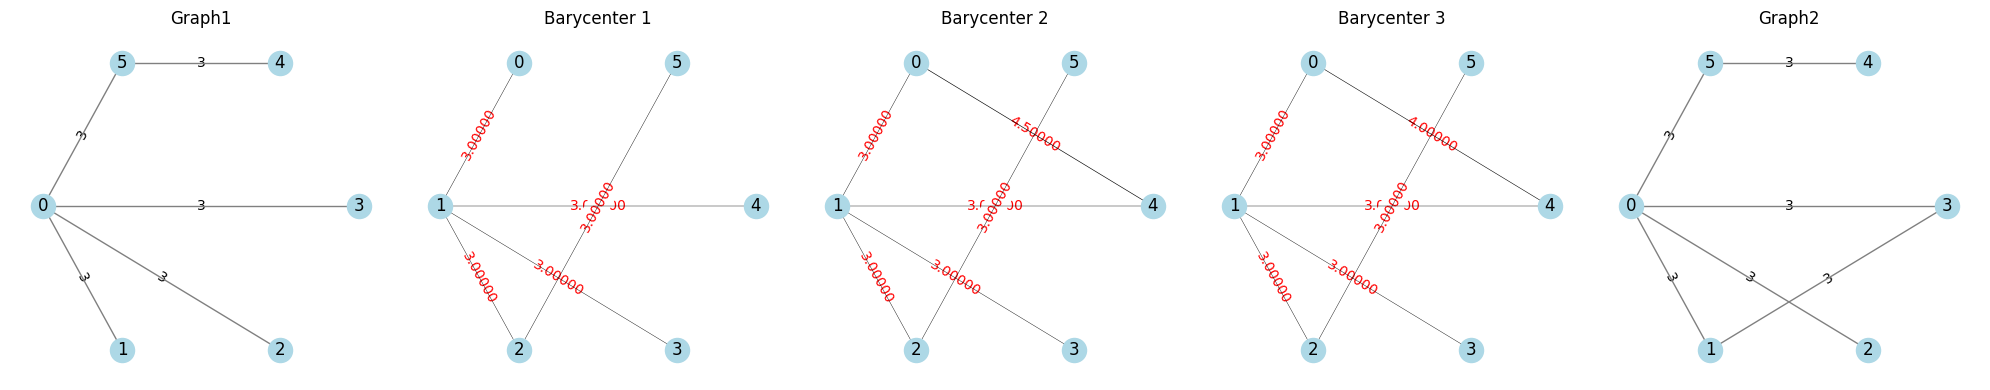

In [44]:
def rotate_positions(pos, angle_degree):
    angle_rad = np.radians(angle_degree)
    rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    rotated_pos = {}
    for node, original_pos in pos.items():
        rotated_pos[node] = np.dot(rotation_matrix, original_pos)
    return rotated_pos


fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax in axes:
  ax.set_facecolor('white')
# Visualize graph1
axes[0].set_title('Graph1')
pos = nx.shell_layout(graph1)
nx.draw_networkx_edge_labels(graph1,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph1.edges(data=True)
                             },
                             ax=axes[0])
nx.draw(graph1,
        pos,
        ax=axes[0],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
# Iterate over weights_list to compute and visualize barycenters
for index, weights in enumerate(weights_list):
  barycenter_matrix = compute_gromov_wasserstein_barycenter(
      graph1, graph2, weights, num_nodes_barycenter)
  # Convert the barycenter's distance matrix to an adjacency matrix using the threshold
  barycenter_adjacency = threshold_distance_matrix(barycenter_matrix,
                                                   upper_threshold)
  # Compute edge weights/exp for visualization
  # barycenter_edges_weight = np.exp(-barycenter_matrix) * barycenter_adjacency
  barycenter_edges_weight = barycenter_matrix * barycenter_adjacency
  # Convert adjacency matrix to graph
  barycenter_graph = nx.from_numpy_array(barycenter_adjacency,
                                         create_using=nx.Graph)
  nx.set_edge_attributes(barycenter_graph, {
      (i, j): barycenter_edges_weight[i, j]
      for i, j in barycenter_graph.edges()
  }, 'weight')
  # Filter and remove edges
  edges_to_remove = [(u, v) for u, v, d in barycenter_graph.edges(data=True)
                     if d['weight'] > 4.5]
  barycenter_graph.remove_edges_from(edges_to_remove)
  # Scale edges based on weights
  edges, weights = zip(
      *nx.get_edge_attributes(barycenter_graph, 'weight').items())
  # Visualize with edge thickness corresponding to weight
  bary_pos = nx.shell_layout(barycenter_graph)
  rotated_pos = rotate_positions(bary_pos, 300)
  axes[index + 1].set_title(f'Barycenter {index + 1}')
  widths = np.array([(w *.1) for w in weights], dtype=float)
  nx.draw_networkx_edge_labels(
      barycenter_graph,
      rotated_pos,
      edge_labels={
          (u, v): f"{d['weight']:.5f}"
          for u, v, d in barycenter_graph.edges(data=True)
          if (u, v) not in edges_to_remove
      },
      font_color='red',
      ax=axes[index + 1])
  nx.draw(barycenter_graph,
          rotated_pos,
          ax=axes[index + 1],
          with_labels=True,
          node_color='lightblue',
          edge_color='black',
          width=widths)
# Visualize graph2
axes[4].set_title('Graph2')
pos = nx.shell_layout(graph2)
nx.draw_networkx_edge_labels(graph2,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph2.edges(data=True)
                             },
                             ax=axes[4])
nx.draw(graph2,
        pos,
        ax=axes[4],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
plt.tight_layout()
plt.savefig('barycenter_graphs_trimmed_and_rotated.png')
plt.show()

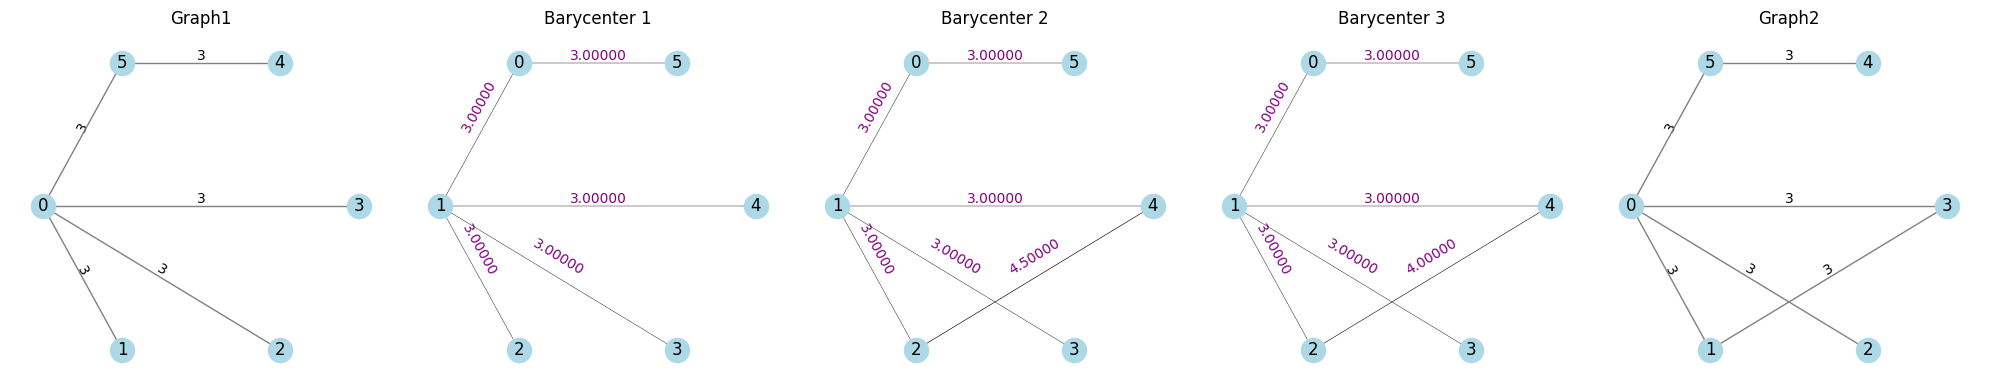

In [52]:
# relabeling of nodes
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax in axes:
  ax.set_facecolor('white')
# Visualize graph1
axes[0].set_title('Graph1')
pos = nx.shell_layout(graph1)
nx.draw_networkx_edge_labels(graph1,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph1.edges(data=True)
                             }, verticalalignment = "bottom",
                             ax=axes[0])
nx.draw(graph1,
        pos,
        ax=axes[0],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
# Iterate over weights_list to compute and visualize barycenters
for index, weights in enumerate(weights_list):
  barycenter_matrix = compute_gromov_wasserstein_barycenter(
      graph1, graph2, weights, num_nodes_barycenter)
  # Convert the barycenter's distance matrix to an adjacency matrix using the threshold
  barycenter_adjacency = threshold_distance_matrix(barycenter_matrix,
                                                   upper_threshold)
  # Compute edge weights/exp for visualization
  # barycenter_edges_weight = np.exp(-barycenter_matrix) * barycenter_adjacency
  barycenter_edges_weight = barycenter_matrix * barycenter_adjacency
  # Apply relabeling to the weight matrix first
  mapping = {0: 2, 2: 0}  # Define a mapping for relabeling
  reordered_weights = barycenter_edges_weight.copy()
  reordered_weights[[0, 2]] = reordered_weights[[2, 0]]  # Swap rows
  reordered_weights[:, [0, 2]] = reordered_weights[:, [2, 0]]  # Swap columns
  
  # Create graph with reordered weights
  barycenter_graph = nx.from_numpy_array(reordered_weights,
                                       create_using=nx.Graph)
  nx.set_edge_attributes(barycenter_graph, {
      (i, j): reordered_weights[i, j]
      for i, j in barycenter_graph.edges()
  }, 'weight')
  # Filter and remove edges
  edges_to_remove = [(u, v) for u, v, d in barycenter_graph.edges(data=True)
                     if d['weight'] > 4.5]
  barycenter_graph.remove_edges_from(edges_to_remove)
  # Scale edges based on weights
  edges, weights = zip(
      *nx.get_edge_attributes(barycenter_graph, 'weight').items())
  # Visualize with edge thickness corresponding to weight
  bary_pos = nx.shell_layout(barycenter_graph)
  rotated_pos = rotate_positions(bary_pos, 300)
  axes[index + 1].set_title(f'Barycenter {index + 1}')
  widths = np.array([(w * 0.1) for w in weights], dtype=float)
  nx.draw_networkx_edge_labels(
      barycenter_graph,
      rotated_pos,
      edge_labels={
          (u, v): f"{d['weight']:.5f}"
          for u, v, d in barycenter_graph.edges(data=True)
          if (u, v) not in edges_to_remove
      },
      font_color='purple', verticalalignment = "bottom",
      ax=axes[index + 1])
  nx.draw(barycenter_graph,
          rotated_pos,
          ax=axes[index + 1],
          with_labels=True,
          node_color='lightblue',
          edge_color='black',
          width=widths)
# Visualize graph2
axes[4].set_title('Graph2')
pos = nx.shell_layout(graph2)
nx.draw_networkx_edge_labels(graph2,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph2.edges(data=True)
                             }, verticalalignment = "bottom",
                             ax=axes[4])
nx.draw(graph2,
        pos,
        ax=axes[4],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
plt.tight_layout()
plt.savefig('barycenter_graphs_trimmed_and_rotated_relabeled.png')
plt.show()

<>:52: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\l'
/var/folders/xz/602zly895c1cm6m7x90nlmth0000gn/T/ipykernel_1088/2195218961.py:52: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title(f'Barycenter, $\lambda_s = 1/2$')


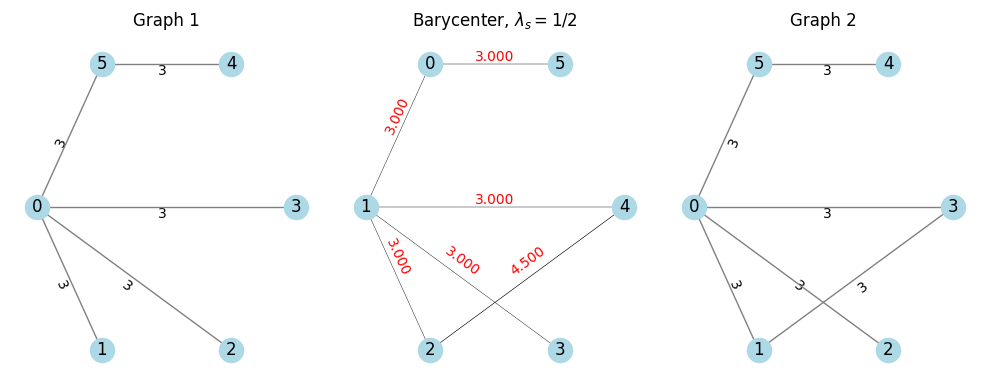

In [48]:
# relabeling of nodes, one barycenter only
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax in axes:
  ax.set_facecolor('white')
# Visualize graph1
axes[0].set_title('Graph 1')
pos = nx.shell_layout(graph1)
nx.draw_networkx_edge_labels(graph1,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph1.edges(data=True)
                             }, horizontalalignment = "right", verticalalignment = "top",
                             ax=axes[0])
nx.draw(graph1,
        pos,
        ax=axes[0],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
# Compute and visualize barycenters
barycenter_matrix = compute_gromov_wasserstein_barycenter(
      graph1, graph2, [0.5,0.5], num_nodes_barycenter)
# Convert the barycenter's distance matrix to an adjacency matrix using the threshold
barycenter_adjacency = threshold_distance_matrix(barycenter_matrix,
                                                   upper_threshold)
# Compute edge weights/exp for visualization
# barycenter_edges_weight = np.exp(-barycenter_matrix) * barycenter_adjacency
barycenter_edges_weight = barycenter_matrix * barycenter_adjacency
# Apply relabeling to the weight matrix first
mapping = {0: 2, 2: 0}  # Define a mapping for relabeling
reordered_weights = barycenter_edges_weight.copy()
reordered_weights[[0, 2]] = reordered_weights[[2, 0]]  # Swap rows
reordered_weights[:, [0, 2]] = reordered_weights[:, [2, 0]]  # Swap columns
  
# Create graph with reordered weights
barycenter_graph = nx.from_numpy_array(reordered_weights,
                                       create_using=nx.Graph)
nx.set_edge_attributes(barycenter_graph, {
      (i, j): reordered_weights[i, j]
      for i, j in barycenter_graph.edges()}, 'weight')

edges_to_remove = [(u, v) for u, v, d in barycenter_graph.edges(data=True)
                     if d['weight'] > 4.5]
barycenter_graph.remove_edges_from(edges_to_remove)
# Scale edges based on weights
edges, weights = zip(
      *nx.get_edge_attributes(barycenter_graph, 'weight').items())
# Visualize with edge thickness corresponding to weight
bary_pos = nx.shell_layout(barycenter_graph)
rotated_pos = rotate_positions(bary_pos, 300)
axes[1].set_title(f'Barycenter, $\lambda_s = 1/2$')
widths = np.array([(w * 0.1) for w in weights], dtype=float)
nx.draw_networkx_edge_labels(
      barycenter_graph,
      rotated_pos,
      edge_labels={
          (u, v): f"{d['weight']:.3f}"
          for u, v, d in barycenter_graph.edges(data=True)
          if (u, v) not in edges_to_remove
      }, verticalalignment = "bottom",
      font_color='red',
      ax=axes[1])
nx.draw(barycenter_graph,
          rotated_pos,
          ax=axes[1],
          with_labels=True,
          node_color='lightblue',
          edge_color='black',
          width=widths)
# Visualize graph2
axes[2].set_title('Graph 2')
pos = nx.shell_layout(graph2)
nx.draw_networkx_edge_labels(graph2,
                             pos,
                             edge_labels={
                                 (u, v): d['weight']
                                 for u, v, d in graph2.edges(data=True)
                             }, horizontalalignment = "left", verticalalignment = "top",
                             ax=axes[2])
nx.draw(graph2,
        pos,
        ax=axes[2],
        with_labels=True,
        node_color='lightblue',
        edge_color='grey')
plt.tight_layout()
plt.savefig('one_barycenter_trimmed_rotated_relabeled.png')
plt.show()